# Logistic Regression

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**



In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease

Creators:

Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.

In [42]:
#Load the data 
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [43]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [44]:
#Changing the target data from number to categorical for readability
df['target'] = df['target'].map({1: "Heart disease", 0:"No heart disease"})

In [45]:
df['target'].value_counts()

target
Heart disease       165
No heart disease    138
Name: count, dtype: int64

In [46]:
#Split into X and y

X = df.drop('target',axis=1)
y = df['target']

In [47]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3




## Train | Test Split 


In [48]:
from sklearn.model_selection import train_test_split

In [49]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

# Grid Search 

We can search through a variety of combinations of hyperparameters with a grid search. While many linear models are quite simple and even come with their own specialized versions that do a search for you, this method of a grid search will can be applied to *any* model from sklearn.




In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [11]:
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |  
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |  
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted
 |  (and copied).
 |  
 |  The 'newton-cg', 'sag', and 'lbfgs' solvers s

## Grid Search

A search consists of:

* an estimator (regressor or classifier);
* a parameter space;
* a method for searching or sampling candidates;
* a cross-validation scheme 

In [51]:
# Penalty Type
penalty = ['l1', 'l2']

# Use logarithmically spaced C values (recommended in official docs)
c = np.logspace(0, 4, 10)

In [52]:
c

array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04])

In [53]:
X_train.shape

(227, 13)

In [54]:
log_model = LogisticRegression(max_iter=5000)

In [55]:
param_grid = {"C" : c, "penalty" : penalty}

grid_model = GridSearchCV(log_model,param_grid= param_grid, cv=5, verbose=2)

In [57]:
#Train model

grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ..................................C=1.0, penalty=l1; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l1; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l1; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l1; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l1; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.0s
[CV] END ..................................C=1.0, penalty=l2; total time=   0.0s
[CV] END ...................C=2.7825594022071245, penalty=l1; total time=   0.0s
[CV] END ...................C=2.782559402207124

C:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _che

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']},
             verbose=2)

In [58]:
#Model best parameter from the grid search
grid_model.best_params_

{'C': 1.0, 'penalty': 'l2'}

In [19]:
grid_model.best_score_

0.846183574879227

In [20]:
#Evaluation
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay, accuracy_score

In [59]:
y_pred = grid_model.predict(X_test)

In [60]:
y_pred

array(['No heart disease', 'Heart disease', 'Heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'No heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'No heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'Heart disease', 'Heart disease',
       'No heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'No heart disease', 'No heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'Heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'Heart disease', 'Heart disease',
       'No heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'Heart disease', '

In [61]:
#Model Accuracy 

accuracy = accuracy_score(y_test , y_pred)

print(f"Accuracy of the model = {accuracy:.2f}") # Round of to two decimal place

Accuracy of the model = 0.83


In [62]:
#Confusin Matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[36,  3],
       [10, 27]], dtype=int64)

In [63]:
grid_model.classes_

array(['Heart disease', 'No heart disease'], dtype=object)

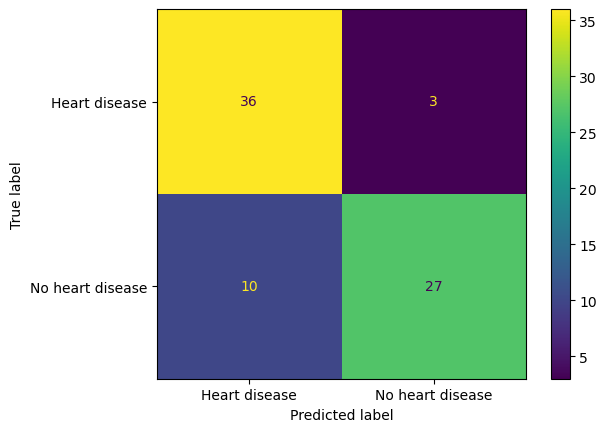

In [64]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_model.classes_)
disp.plot()

plt.show()

In [26]:
 X_test.shape

(76, 13)

In [65]:
#Classification report 
print(classification_report(y_test,y_pred))

                  precision    recall  f1-score   support

   Heart disease       0.78      0.92      0.85        39
No heart disease       0.90      0.73      0.81        37

        accuracy                           0.83        76
       macro avg       0.84      0.83      0.83        76
    weighted avg       0.84      0.83      0.83        76



## Experimenting with other Models 

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier , AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [66]:
def run_model(model , x_train , x_test , y_train , y_test):
    model.fit(x_train ,y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test , y_pred)
    print(f"Accuracy of the model {model} : {accuracy:.2f}") #Round of to two decimal places

In [67]:
decision_tree = DecisionTreeClassifier(random_state=101)
rf = RandomForestClassifier(random_state=101)
knn = KNeighborsClassifier()
Gradient_boost = GradientBoostingClassifier(random_state=101)
Ada_boost = AdaBoostClassifier(random_state=101)

In [68]:
for model in [decision_tree , rf , knn , Gradient_boost, Ada_boost]:
    run_model(model , X_train, X_test , y_train , y_test)

Accuracy of the model DecisionTreeClassifier(random_state=101) : 0.76
Accuracy of the model RandomForestClassifier(random_state=101) : 0.86
Accuracy of the model KNeighborsClassifier() : 0.64
Accuracy of the model GradientBoostingClassifier(random_state=101) : 0.82
Accuracy of the model AdaBoostClassifier(random_state=101) : 0.84


### Perform Grid search on Randorm Forest

In [32]:
rf = RandomForestClassifier(random_state=101)

In [33]:
help(RandomForestClassifier())

Help on RandomForestClassifier in module sklearn.ensemble._forest object:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |  
 |  A random forest classifier.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
 |  The sub-sample size is controlled with the `max_samples` parame

In [72]:
param_rf={'n_estimators':[20,30,40,50,100],
         'max_depth':list(range(1,11)),
         'max_features':list(range(1,11))}

In [71]:
grid_rf = GridSearchCV(rf , param_grid=param_rf, cv=5, verbose=2)

In [73]:

run_model(grid_rf , X_train, X_test , y_train , y_test)

Fitting 5 folds for each of 600 candidates, totalling 3000 fits
[CV] END .......max_depth=1, max_features=1, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=1, max_features=1, 

[CV] END .......max_depth=1, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=1, max_features=4, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=1, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=1, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=1, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=1, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=1, 

[CV] END ......max_depth=1, max_features=7, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=1, max_features=7, n_estimators=200; total time=   0.1s
[CV] END ......max_depth=1, max_features=7, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=1, max_features=7, n_estimators=200; total time=   0.1s
[CV] END ......max_depth=1, max_features=7, n_estimators=200; total time=   0.1s
[CV] END ......max_depth=1, max_features=7, n_estimators=200; total time=   0.1s
[CV] END .......max_depth=1, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=1, max_features=8, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=1,

[CV] END .......max_depth=2, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=30; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=2,

[CV] END ......max_depth=2, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=4, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=2, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=4, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=4, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=2, max_features=4, n_estimators=200; total time=   0.1s
[CV] END ......max_depth=2, max_features=4, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=2, max_features=4, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=2, max_features=4, n_estimators=200; total time=   0.2s
[CV] END .......max_depth=2, max_features=5, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=2, max_features=5, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=2,

...

[CV] END .......max_depth=9, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=40; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=9, max_features=4, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=9, max_features=4, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=9, max_features=4, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=9, 

[CV] END ......max_depth=9, max_features=7, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=9, max_features=7, n_estimators=100; total time=   0.1s
[CV] END ......max_depth=9, max_features=7, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=9, max_features=7, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=9, max_features=7, n_estimators=200; total time=   0.3s
[CV] END ......max_depth=9, max_features=7, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=9, max_features=7, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=9, max_features=7, n_estimators=200; total time=   0.2s
[CV] END .......max_depth=9, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=9, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=9, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=9, max_features=8, n_estimators=20; total time=   0.0s
[CV] END .......max_depth=9,

[CV] END ......max_depth=10, max_features=1, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=10, max_features=1, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=10,

[CV] END ......max_depth=10, max_features=4, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=10, max_features=4, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=10, max_features=4, n_estimators=50; total time=   0.0s
[CV] END .....max_depth=10, max_features=4, n_estimators=100; total time=   0.0s
[CV] END .....max_depth=10, max_features=4, n_estimators=100; total time=   0.0s
[CV] END .....max_depth=10, max_features=4, n_estimators=100; total time=   0.0s
[CV] END .....max_depth=10, max_features=4, n_estimators=100; total time=   0.1s
[CV] END .....max_depth=10, max_features=4, n_estimators=100; total time=   0.0s
[CV] END .....max_depth=10, max_features=4, n_estimators=200; total time=   0.2s
[CV] END .....max_depth=10, max_features=4, n_estimators=200; total time=   0.2s
[CV] END .....max_depth=10, max_features=4, n_estimators=200; total time=   0.2s
[CV] END .....max_depth=10, max_features=4, n_estimators=200; total time=   0.2s
[CV] END .....max_depth=10, 

[CV] END .....max_depth=10, max_features=7, n_estimators=200; total time=   0.2s
[CV] END ......max_depth=10, max_features=8, n_estimators=20; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=20; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=20; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=20; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=20; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=30; total time=   0.0s
[CV] END ......max_depth=10, max_features=8, n_estimators=40; total time=   0.0s
[CV] END ......max_depth=10,

In [74]:
grid_rf.best_params_

{'max_depth': 4, 'max_features': 1, 'n_estimators': 200}

In [75]:
ft_import = grid_rf.best_estimator_.feature_importances_

In [76]:
feat = pd.DataFrame(ft_import, index = X.columns, columns=['Feature_importance']).sort_values("Feature_importance")


<Axes: >

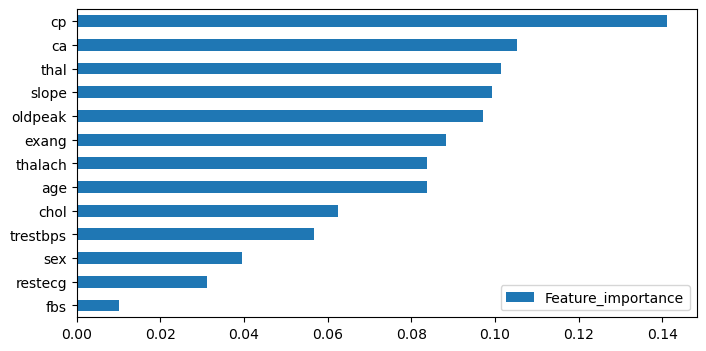

In [77]:
feat.plot(kind='barh', figsize=(8,4))


In [79]:
import joblib

In [80]:
joblib.dump(rf , "rf.pkl")

['rf.pkl']

In [82]:
loaded_model = joblib.load('rf.pkl')

In [83]:
loaded_model.predict(X_test)

array(['No heart disease', 'Heart disease', 'Heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'No heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'No heart disease', 'Heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'Heart disease', 'Heart disease',
       'No heart disease', 'No heart disease', 'Heart disease',
       'No heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'No heart disease', 'No heart disease', 'No heart disease',
       'Heart disease', 'No heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'Heart disease', 'Heart disease',
       'Heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'Heart disease', 'Heart disease',
       'No heart disease', 'Heart disease', 'No heart disease',
       'Heart disease', 'Heart disease', '